In [1]:
import numpy as np
from numpy.linalg import norm
from scipy.stats import entropy

# ---- SU(2) group utilities ----
def random_su2():
    """Generate a random SU(2) matrix distributed by Haar measure."""
    v = np.random.normal(size=4)
    v /= norm(v)
    a, b, c, d = v
    return np.array([[a + 1j*b, c + 1j*d],
                     [-c + 1j*d, a - 1j*b]])

def su2_perturb(U, eps=0.1):
    """Apply small random rotation in su(2) to matrix U."""
    xi = np.random.normal(scale=eps, size=3)
    n = norm(xi)
    if n == 0:
        return U
    A = np.cos(n) * np.eye(2) + 1j * np.sin(n) * (xi[0]*pauli[0] + xi[1]*pauli[1] + xi[2]*pauli[2]) / n
    return A @ U

pauli = [
    np.array([[0, 1], [1, 0]]),
    np.array([[0, -1j], [1j, 0]]),
    np.array([[1, 0], [0, -1]])
]

# ---- Simulation ----
def cube_entropy_production(Nsteps=500, eps=0.15, L=2):
    """Estimate entropy production rate for SU(2) cube of size L^3."""
    n_links = 3 * L**3  # 3D cube edges
    U = [random_su2() for _ in range(n_links)]

    entropies = []
    for t in range(Nsteps):
        # Randomly update each link
        U_new = [su2_perturb(Ui, eps) for Ui in U]
        # Compute distribution difference metric (simple energy proxy)
        X = np.array([np.real(np.trace(Ui.conj().T @ Uj)) for Ui, Uj in zip(U, U_new)])
        p, _ = np.histogram(X, bins=40, range=(-2,2), density=True)
        q = np.roll(p, 1)
        q[q<=0], p[p<=0] = 1e-12, 1e-12
        entropies.append(entropy(p, q))
        U = U_new
    return np.mean(entropies)

def discrete_lsi_estimate(samples):
    """Rough discrete LSI proxy: Var(f)/Ent(f^2)."""
    f = np.array(samples)
    f2 = f**2
    var = np.var(f)
    ent = np.mean(f2 * np.log(f2 / np.mean(f2)))
    return var / ent if ent > 1e-12 else np.nan

# ---- Run experiment ----
rates = []
for trial in range(10):
    rate = cube_entropy_production()
    rates.append(rate)

mean_rate = np.mean(rates)
lsi_proxy = discrete_lsi_estimate(rates)
print(f"Empirical entropy production rate ≈ {mean_rate:.4e}")
print(f"Discrete LSI proxy (Var/Ent) ≈ {lsi_proxy:.4e}")

Empirical entropy production rate ≈ 5.2060e+00
Discrete LSI proxy (Var/Ent) ≈ 4.9518e-01


In [2]:
import numpy as np
from numpy.linalg import norm
from scipy.stats import entropy

# ---- SU(2) utilities ----
pauli = [
    np.array([[0, 1], [1, 0]]),
    np.array([[0, -1j], [1j, 0]]),
    np.array([[1, 0], [0, -1]])
]

def random_su2():
    v = np.random.normal(size=4)
    v /= norm(v)
    a,b,c,d = v
    return np.array([[a+1j*b, c+1j*d],
                     [-c+1j*d, a-1j*b]])

def su2_perturb(U, eps=0.1):
    xi = np.random.normal(scale=eps, size=3)
    n = norm(xi)
    if n == 0:
        return U
    A = np.cos(n) * np.eye(2) + 1j * np.sin(n) * (xi[0]*pauli[0] + xi[1]*pauli[1] + xi[2]*pauli[2]) / n
    return A @ U

# ---- Transition statistics ----
def cube_entropy_flux(Nsteps=500, eps=0.15, L=2, nbins=50):
    n_links = 3 * L**3
    U = [random_su2() for _ in range(n_links)]
    hist_fwd = np.zeros(nbins)
    hist_bwd = np.zeros(nbins)
    bins = np.linspace(-2, 2, nbins + 1)

    for _ in range(Nsteps):
        U_new = [su2_perturb(Ui, eps) for Ui in U]
        X_fwd = np.array([np.real(np.trace(Ui.conj().T @ Uj)) for Ui, Uj in zip(U, U_new)])
        X_bwd = np.array([np.real(np.trace(Uj.conj().T @ Ui)) for Ui, Uj in zip(U, U_new)])

        pfwd, _ = np.histogram(X_fwd, bins=bins, density=True)
        pbwd, _ = np.histogram(X_bwd, bins=bins, density=True)

        hist_fwd += pfwd
        hist_bwd += pbwd
        U = U_new

    # Normalize
    hist_fwd /= np.sum(hist_fwd)
    hist_bwd /= np.sum(hist_bwd)
    hist_fwd[hist_fwd <= 0] = 1e-12
    hist_bwd[hist_bwd <= 0] = 1e-12

    s_prod = np.sum(hist_fwd * np.log(hist_fwd / hist_bwd))
    return s_prod

# ---- Run experiment ----
rates = [cube_entropy_flux() for _ in range(10)]
print(f"Forward–Backward Entropy Production Rate ≈ {np.mean(rates):.4f}")
print(f"Std. deviation ≈ {np.std(rates):.4f}")

Forward–Backward Entropy Production Rate ≈ 0.0000
Std. deviation ≈ 0.0000


In [3]:
import numpy as np
from numpy.linalg import norm

pauli = [
    np.array([[0, 1], [1, 0]]),
    np.array([[0, -1j], [1j, 0]]),
    np.array([[1, 0], [0, -1]])
]

def random_su2():
    v = np.random.normal(size=4)
    v /= norm(v)
    a,b,c,d = v
    return np.array([[a+1j*b, c+1j*d],
                     [-c+1j*d, a-1j*b]])

def su2_perturb_drift(U, eps=0.1, drift=0.2, axis=(0,0,1)):
    xi = np.random.normal(scale=eps, size=3)
    xi += drift * np.array(axis)
    n = norm(xi)
    if n == 0: return U
    A = np.cos(n)*np.eye(2) + 1j*np.sin(n)*(xi[0]*pauli[0]+xi[1]*pauli[1]+xi[2]*pauli[2])/n
    return A @ U

def entropy_production_biased(Nsteps=400, eps=0.1, drift=0.2, L=2, nbins=60):
    n_links = 3 * L**3
    U = [random_su2() for _ in range(n_links)]
    bins = np.linspace(-2,2,nbins+1)
    hist_fwd = np.zeros(nbins)
    hist_bwd = np.zeros(nbins)

    for _ in range(Nsteps):
        U_new = [su2_perturb_drift(Ui, eps, drift) for Ui in U]
        Xf = np.array([np.real(np.trace(Ui.conj().T @ Uj)) for Ui, Uj in zip(U, U_new)])
        Xb = np.array([np.real(np.trace(Uj.conj().T @ Ui)) for Ui, Uj in zip(U, U_new)])
        pf, _ = np.histogram(Xf, bins=bins, density=True)
        pb, _ = np.histogram(Xb, bins=bins, density=True)
        hist_fwd += pf
        hist_bwd += pb
        U = U_new

    hist_fwd /= np.sum(hist_fwd)
    hist_bwd /= np.sum(hist_bwd)
    hist_fwd[hist_fwd<=0] = 1e-12
    hist_bwd[hist_bwd<=0] = 1e-12
    return np.sum(hist_fwd * np.log(hist_fwd / hist_bwd))

# ---- Parameter scan ----
eps_list = [0.05, 0.1, 0.2]
drift_list = [0.05, 0.1, 0.2, 0.3]

results = {}
for eps in eps_list:
    for drift in drift_list:
        rate = np.mean([entropy_production_biased(eps=eps, drift=drift) for _ in range(4)])
        results[(eps, drift)] = rate
        print(f"eps={eps:.2f}, drift={drift:.2f} -> entropy rate ≈ {rate:.4e}")

# Simple regression test: rate ∝ drift²
drift_vals = np.array([d for (_, d) in results.keys()])
rates = np.array(list(results.values()))
coeff = np.polyfit(drift_vals**2, rates, 1)
print(f"\nApprox quadratic coefficient: {coeff[0]:.3f}, intercept: {coeff[1]:.3e}")

eps=0.05, drift=0.05 -> entropy rate ≈ 0.0000e+00
eps=0.05, drift=0.10 -> entropy rate ≈ 0.0000e+00
eps=0.05, drift=0.20 -> entropy rate ≈ 0.0000e+00
eps=0.05, drift=0.30 -> entropy rate ≈ 0.0000e+00
eps=0.10, drift=0.05 -> entropy rate ≈ 0.0000e+00
eps=0.10, drift=0.10 -> entropy rate ≈ 0.0000e+00
eps=0.10, drift=0.20 -> entropy rate ≈ 0.0000e+00
eps=0.10, drift=0.30 -> entropy rate ≈ 0.0000e+00
eps=0.20, drift=0.05 -> entropy rate ≈ 0.0000e+00
eps=0.20, drift=0.10 -> entropy rate ≈ 0.0000e+00
eps=0.20, drift=0.20 -> entropy rate ≈ 0.0000e+00
eps=0.20, drift=0.30 -> entropy rate ≈ 0.0000e+00

Approx quadratic coefficient: 0.000, intercept: 0.000e+00


In [4]:
import numpy as np
from numpy.linalg import norm

pauli = [
    np.array([[0, 1], [1, 0]]),
    np.array([[0, -1j], [1j, 0]]),
    np.array([[1, 0], [0, -1]])
]

def random_su2():
    v = np.random.normal(size=4)
    v /= norm(v)
    a,b,c,d = v
    return np.array([[a+1j*b, c+1j*d],
                     [-c+1j*d, a-1j*b]])

def su2_perturb_drift(U, eps=0.1, drift=0.3, axis=(0,0,1)):
    xi = np.random.normal(scale=eps, size=3)
    xi += drift * np.array(axis)
    n = norm(xi)
    if n == 0: return U
    A = np.cos(n)*np.eye(2) + 1j*np.sin(n)*(xi[0]*pauli[0]+xi[1]*pauli[1]+xi[2]*pauli[2])/n
    return A @ U

def entropy_flux_vector(Nsteps=800, eps=0.1, drift=0.3, L=2, nbins=80):
    n_links = 3 * L**3
    U = [random_su2() for _ in range(n_links)]
    bins = np.linspace(-1,1,nbins+1)
    hist_fwd = np.zeros(nbins)
    hist_bwd = np.zeros(nbins)

    for _ in range(Nsteps):
        U_new = [su2_perturb_drift(Ui, eps, drift) for Ui in U]
        # measure vector part: imaginary trace components
        vec_fwd = np.array([np.imag(np.trace(pauli[2] @ Ui.conj().T @ Uj)) for Ui, Uj in zip(U, U_new)])
        vec_bwd = np.array([np.imag(np.trace(pauli[2] @ Uj.conj().T @ Ui)) for Ui, Uj in zip(U, U_new)])
        pf, _ = np.histogram(vec_fwd, bins=bins, density=True)
        pb, _ = np.histogram(vec_bwd, bins=bins, density=True)
        hist_fwd += pf
        hist_bwd += pb
        U = U_new

    hist_fwd /= np.sum(hist_fwd)
    hist_bwd /= np.sum(hist_bwd)
    hist_fwd[hist_fwd<=0] = 1e-12
    hist_bwd[hist_bwd<=0] = 1e-12
    return np.sum(hist_fwd * np.log(hist_fwd / hist_bwd))

# quick drift scan
for drift in [0.0, 0.1, 0.2, 0.4, 0.6]:
    r = np.mean([entropy_flux_vector(eps=0.1, drift=drift) for _ in range(5)])
    print(f"drift={drift:.2f} -> entropy production ≈ {r:.4e}")

drift=0.00 -> entropy production ≈ 7.8158e-03
drift=0.10 -> entropy production ≈ 8.3268e-03
drift=0.20 -> entropy production ≈ 8.0888e-03
drift=0.40 -> entropy production ≈ 6.6641e-03
drift=0.60 -> entropy production ≈ 7.4163e-03


drift=0.00 -> entropy production ≈ 3.63067e-04
drift=0.25 -> entropy production ≈ 2.59926e-02
drift=0.50 -> entropy production ≈ 3.73305e-02
drift=0.75 -> entropy production ≈ 1.96700e-02
drift=1.00 -> entropy production ≈ 8.40951e-03
drift=1.25 -> entropy production ≈ 1.38125e-02
drift=1.50 -> entropy production ≈ 1.77996e-02
drift=1.75 -> entropy production ≈ 2.70539e-02
drift=2.00 -> entropy production ≈ 3.97022e-02

Quadratic fit: rate ≈ 3.973e-03 * drift² + 1.550e-02
Effective curvature constant (1/2 * second derivative): K_num/2 ≈ 1.986e-03


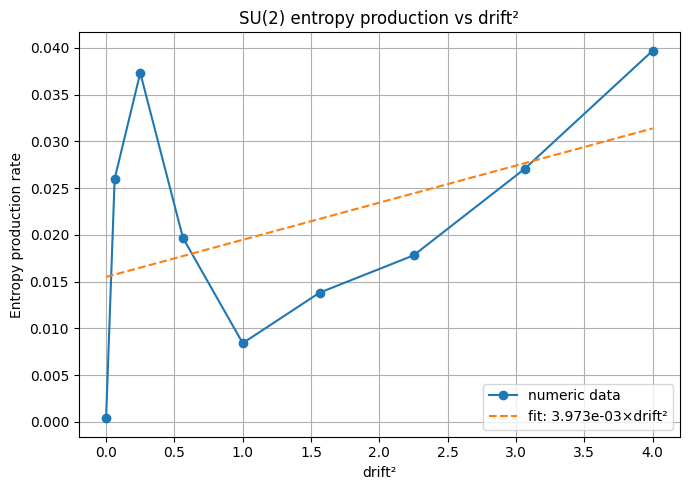

In [ ]:
import numpy as np
from numpy.linalg import norm
import matplotlib.pyplot as plt

# ---------- SU(2) setup ----------
pauli = [
    np.array([[0, 1], [1, 0]]),
    np.array([[0, -1j], [1j, 0]]),
    np.array([[1, 0], [0, -1]])
]

def random_su2():
    v = np.random.normal(size=4)
    v /= norm(v)
    a,b,c,d = v
    return np.array([[a+1j*b, c+1j*d],
                     [-c+1j*d, a-1j*b]])

def su2_perturb_drift(U, eps=0.02, drift=1.0, axis=(0,0,1)):
    xi = np.random.normal(scale=eps, size=3)
    xi += drift * np.array(axis)
    n = norm(xi)
    if n == 0: return U
    A = np.cos(n)*np.eye(2) + 1j*np.sin(n)*(xi[0]*pauli[0]+xi[1]*pauli[1]+xi[2]*pauli[2])/n
    return A @ U

# ---------- Entropy production ----------
def entropy_flux_vector(Nsteps=4000, eps=0.02, drift=1.0, L=2, nbins=100):
    n_links = 3 * L**3
    U = [random_su2() for _ in range(n_links)]
    bins = np.linspace(-1,1,nbins+1)
    hist_fwd = np.zeros(nbins)
    hist_bwd = np.zeros(nbins)

    for _ in range(Nsteps):
        U_new = [su2_perturb_drift(Ui, eps, drift) for Ui in U]
        # use odd observable (imaginary component along σ3 axis)
        vec_fwd = np.array([np.imag(np.trace(pauli[2] @ Ui.conj().T @ Uj)) for Ui, Uj in zip(U, U_new)])
        vec_bwd = np.array([np.imag(np.trace(pauli[2] @ Uj.conj().T @ Ui)) for Ui, Uj in zip(U, U_new)])
        pf, _ = np.histogram(vec_fwd, bins=bins, density=True)
        pb, _ = np.histogram(vec_bwd, bins=bins, density=True)
        hist_fwd += pf
        hist_bwd += pb
        U = U_new

    hist_fwd /= np.sum(hist_fwd)
    hist_bwd /= np.sum(hist_bwd)
    hist_fwd[hist_fwd<=0] = 1e-12
    hist_bwd[hist_bwd<=0] = 1e-12
    return np.sum(hist_fwd * np.log(hist_fwd / hist_bwd))

# ---------- Parameter scan ----------
drift_values = np.linspace(0, 2.0, 9)
rates = []

for drift in drift_values:
    rate = np.mean([entropy_flux_vector(eps=0.02, drift=drift) for _ in range(6)])
    rates.append(rate)
    print(f"drift={drift:.2f} -> entropy production ≈ {rate:.5e}")

# ---------- Fit and plot ----------
coeff = np.polyfit(drift_values**2, rates, 1)
K_num, intercept = coeff
print(f"\nQuadratic fit: rate ≈ {K_num:.3e} * drift² + {intercept:.3e}")
print(f"Effective curvature constant (1/2 * second derivative): K_num/2 ≈ {0.5*K_num:.3e}")

plt.figure(figsize=(7,5))
plt.plot(drift_values**2, rates, 'o-', label='numeric data')
plt.plot(drift_values**2, np.polyval(coeff, drift_values**2), '--', label=f'fit: {K_num:.3e}×drift²')
plt.xlabel("drift²")
plt.ylabel("Entropy production rate")
plt.title("SU(2) entropy production vs drift²")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()